#### Setup

In [15]:
import pickle
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Parameters

In [ ]:
BATCH_SIZE = 128
NUM_WORKERS = 0
EPOCHS = 5
VAL_SPLIT = 0.1
IMG_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


#### Loading data structure from .pkl

In [4]:
train_videos = pickle.load(open("train_structure.pkl", "rb"))
test_videos  = pickle.load(open("test_structure.pkl", "rb"))

classes = sorted(train_videos.keys())
num_classes = len(classes)
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

print("Number of classes:", num_classes)
print("Loaded train videos:", len(train_videos))

Number of classes: 14
Loaded train videos: 14


#### Class for creating a dataset based on video frames

In [5]:
class CrimeDataset(Dataset):
    def __init__(self, videos_dict, transform=None):
        self.samples = []
        self.transform = transform
        for cls_name, videos in videos_dict.items():
            label = class_to_idx[cls_name]
            for video_name, video_info in videos.items():
                for frame_path in video_info["frames"]:
                    self.samples.append((Path(frame_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

#### Transform

In [6]:
transform = transforms.Compose([
    transforms.ToTensor()
])

#### Creating complete datasets and DataLoaders

In [ ]:
full_dataset = CrimeDataset(train_videos, transform=transform)
val_size = int(VAL_SPLIT * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
test_dataset = CrimeDataset(test_videos, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

#### Creating the EfficientNet-B0 model

In [ ]:
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# Setting up the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#### Functions for training and validation

In [10]:
def train_epoch():
    model.train()
    correct = 0
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

def validate_epoch():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

#### Training and saving checkpoints

In [12]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if i % 200 == 0:
            print(f"  Batch {i}/{len(train_loader)}  Loss: {loss.item():.4f}")

    checkpoint_path = f"crime_model_vs_epoch{epoch+1}.pth"
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Model checkpoint saved: {checkpoint_path}")


Epoch 1/5
  Batch 0/8903  Loss: 2.5939
  Batch 200/8903  Loss: 0.3715
  Batch 400/8903  Loss: 0.4422
  Batch 600/8903  Loss: 0.4109
  Batch 800/8903  Loss: 0.2008
  Batch 1000/8903  Loss: 0.1306
  Batch 1200/8903  Loss: 0.1093
  Batch 1400/8903  Loss: 0.1338
  Batch 1600/8903  Loss: 0.0931
  Batch 1800/8903  Loss: 0.0812
  Batch 2000/8903  Loss: 0.1038
  Batch 2200/8903  Loss: 0.1433
  Batch 2400/8903  Loss: 0.1540
  Batch 2600/8903  Loss: 0.0570
  Batch 2800/8903  Loss: 0.2474
  Batch 3000/8903  Loss: 0.0317
  Batch 3200/8903  Loss: 0.0298
  Batch 3400/8903  Loss: 0.0415
  Batch 3600/8903  Loss: 0.0372
  Batch 3800/8903  Loss: 0.1515
  Batch 4000/8903  Loss: 0.0128
  Batch 4200/8903  Loss: 0.0974
  Batch 4400/8903  Loss: 0.0492
  Batch 4600/8903  Loss: 0.0123
  Batch 4800/8903  Loss: 0.0288
  Batch 5000/8903  Loss: 0.0343
  Batch 5200/8903  Loss: 0.0661
  Batch 5400/8903  Loss: 0.0389
  Batch 5600/8903  Loss: 0.1022
  Batch 5800/8903  Loss: 0.0332
  Batch 6000/8903  Loss: 0.0053
  Ba

#### Model loading

In [18]:
model.load_state_dict(torch.load("crime_model_vs_epoch5.pth", map_location=device))
model.to(device)
model.eval()

C:\Users\user\AppData\Local\Temp\ipykernel_9640\639922482.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("crime_model_vs_epoch5.pth", m

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Test

In [16]:
all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

Test Accuracy: 0.5582

Classification Report:
               precision    recall  f1-score   support

        Abuse       0.00      0.00      0.00       297
       Arrest       0.04      0.04      0.04      3365
        Arson       0.23      0.18      0.20      2793
      Assault       0.01      0.00      0.01      2657
     Burglary       0.05      0.01      0.02      7657
    Explosion       0.09      0.01      0.02      6510
     Fighting       0.00      0.00      0.00      1231
 NormalVideos       0.71      0.93      0.80     64952
RoadAccidents       0.06      0.06      0.06      2663
      Robbery       0.00      0.00      0.00       835
     Shooting       0.00      0.00      0.00      7630
  Shoplifting       0.91      0.05      0.09      7623
     Stealing       0.05      0.11      0.06      1984
    Vandalism       0.00      0.00      0.00      1111

     accuracy                           0.56    111308
    macro avg       0.15      0.10      0.09    111308
 weighted avg    

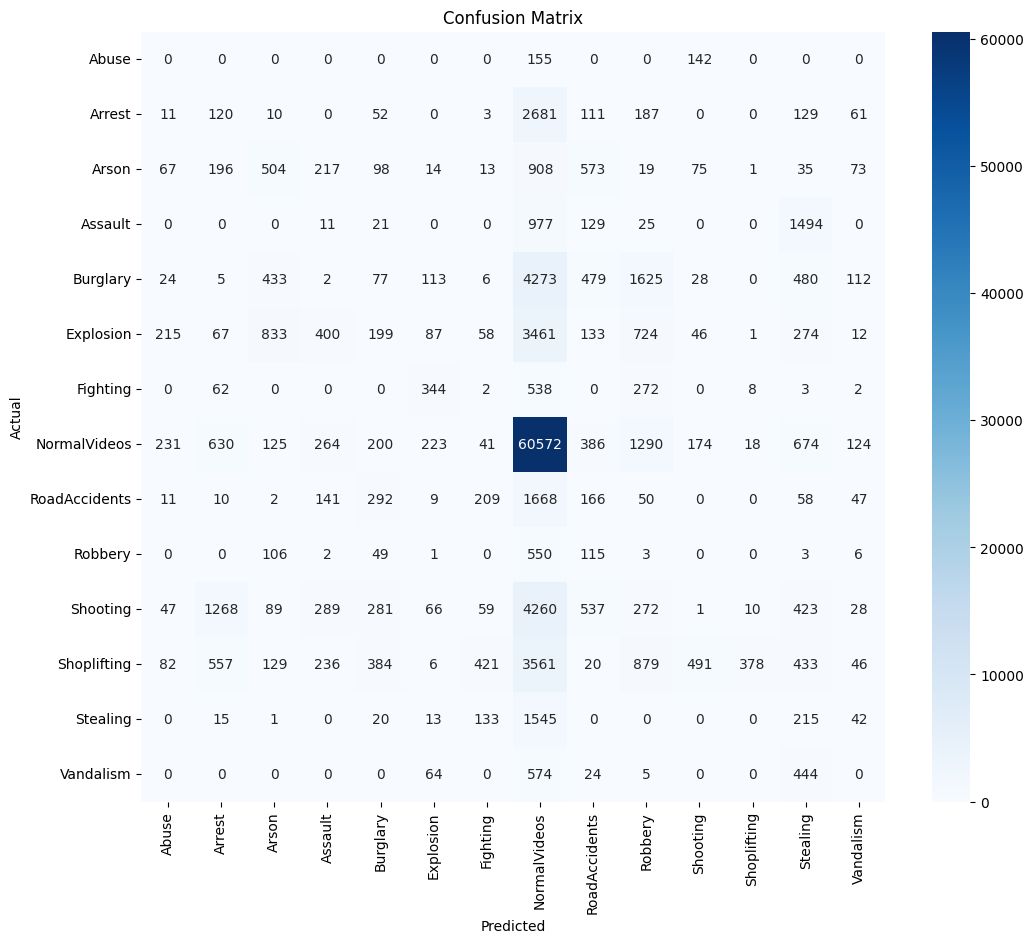

In [ ]:
accuracy = np.mean(np.array(all_labels) == np.array(all_preds))
print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()